In [1]:
print('hi')

hi


In [2]:
from pydantic import BaseModel, Field
from typing import Annotated, Sequence, TypedDict, Literal
from langchain_core.messages import BaseMessage, AIMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
import operator
from typing import List, TypedDict, Annotated, Sequence
from langgraph.graph.message import add_messages
from IPython.display import Image, display
from langchain_core.messages import HumanMessage, SystemMessage
from langchain.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain.tools import tool
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools import create_retriever_tool
from langsmith.client import Client

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
load_dotenv()
os.environ['OPENAI_API_KEY']=os.getenv('OPENAI_API_KEY')

In [4]:
llm = ChatOpenAI(model="gpt-4o")
llm.invoke("What is the weather in Tokyo?")

AIMessage(content="I'm unable to provide real-time weather updates as my training only includes information up until October 2023, and I don't have access to the internet to check current conditions. I recommend checking a reliable weather website or app for the latest weather information for Tokyo.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 14, 'total_tokens': 65, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_d737a10594', 'id': 'chatcmpl-DXhmGkf6chea1DPyRXt5dvrSlkgDA', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019db903-020f-7fc1-aaef-7d10dccdf430-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'outp

In [5]:
from langgraph.types import Command
from langgraph.prebuilt import create_react_agent ## In built class for react agent -> pass model name and tool


In [6]:
def add_number(state):
    result=state['num1']+state['num2']
    print(f"The sum of {state['num1']} and {state['num2']} is {result}")
    return Command(goto="multiply", update={"sum":result})

    # The command has some parameters out of which the goto and update are important.
    # goto means -> which function next we have to go to.
    # update means -> update the state with the new key value pair.

In [7]:
state={"num1":10, "num2":20}

In [8]:
add_number(state)

The sum of 10 and 20 is 30


Command(update={'sum': 30}, goto='multiply')

#### ### Creating dumy multi agent for Network / Supervisor Multi Agent

In [9]:
@tool
def transfer_to_multiplication_expert():
    """Ask multiplication agent for help"""
    return

In [10]:
@tool
def transfer_to_addition_expert():
    """Ask addition agent for help"""
    return

In [11]:
llm_with_tool=llm.bind_tools([transfer_to_addition_expert])

In [12]:
response=llm_with_tool.invoke("hi")

In [13]:
response.content

'Hello! How can I assist you today?'

In [14]:
response.tool_calls

[]

In [15]:
response=llm_with_tool.invoke("What is 2 multiply by 2?")

In [16]:
response.content

'2 multiplied by 2 equals 4.'

In [17]:
response.tool_calls

[]

In [18]:
system_prompt = (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )

In [19]:
messages = [{"role": "system", "content": system_prompt}] + ["can you tell me the addition of 2 and 2?"]

In [20]:
messages

[{'role': 'system',
  'content': 'You are an addition expert, you can ask the multiplication expert for help with multiplication.Always do your portion of calculation before the handoff.'},
 'can you tell me the addition of 2 and 2?']

In [21]:
def additional_expert(state:MessagesState)-> Command[Literal["multiplication_expert", "__end__"]]:
    
    system_prompt = (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    
    ai_msg = llm.bind_tools([transfer_to_multiplication_expert]).invoke(messages)
    
    
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        
        return Command(
            goto="multiplication_expert", update={"messages": [ai_msg, tool_msg]}
        )
    return {"messages": [ai_msg]}

In [22]:
##Agent2
def multiplication_expert(state:MessagesState)-> Command[Literal["additional_expert", "__end__"]]:
    
    system_prompt = (
        "You are a multiplication expert, you can ask an addition expert for help with addition. "
        "Always do your portion of calculation before the handoff."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    ai_msg = llm.bind_tools([transfer_to_addition_expert]).invoke(messages)
    
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        return Command(goto="additional_expert", update={"messages": [ai_msg, tool_msg]})
    return {"messages": [ai_msg]}

In [23]:
graph=StateGraph(MessagesState)

In [24]:
graph.add_node('additional_expert', additional_expert)

In [25]:
graph.add_node('multiplication_expert', multiplication_expert)

In [26]:
graph.add_edge(START, 'additional_expert')

In [27]:
app=graph.compile()

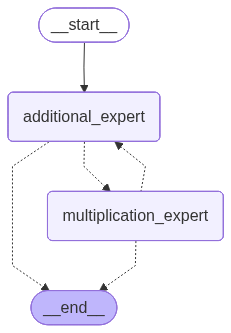

In [28]:
display(Image(app.get_graph().draw_mermaid_png()))

In [29]:
app.invoke({"messages":[("user","what's (3 + 5) * 12. Provide me the output")]})

{'messages': [HumanMessage(content="what's (3 + 5) * 12. Provide me the output", additional_kwargs={}, response_metadata={}, id='f3891afa-da97-4f3d-9b4e-e1166750da91'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 86, 'total_tokens': 101, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_83fa6aca3f', 'id': 'chatcmpl-DXhmPUQBYwbevgx390ZpJ8mr0ikxU', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019db903-241f-7352-a919-7fc7519cdc55-0', tool_calls=[{'name': 'transfer_to_multiplication_expert', 'args': {}, 'id': 'call_gV6gM2q7EP023FD4CoL5WnFt', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_toke

In [33]:
## With realtime tool
from langchain_community.tools import DuckDuckGoSearchRun
search_tool=DuckDuckGoSearchRun()

In [34]:
search_tool.invoke("Who is the pm in India?")


'The prime minister is appointed by the president of India ; however, the prime minister has to enjoy the confidence of the majority of Lok Sabha ... But India is a Hindu nation, Hindu civilisation, and we will always believe, and we are extremely confident that the Indian Prime Minister will ... PM Modi is the second Indian leader to win a third term after first prime minister Jawaharlal Nehru. ... The Nepal PM arrived in New Delhi on Sunday ... ... the BJP campaign, Bhupendra Patel, who was installed as chief minister only two months ago after the unceremonious exit of former Chief Minister Vijay ... ... the PM as an “inspiration,” he went on to express: “Every moment of your life, imbued with the sacred spirit of Nation First, dedicated to the ...'

In [36]:
from langchain_experimental.utilities import PythonREPL

In [ ]:
repl=PythonREPL()
## to execute the python tool

In [38]:
code = """
x = 5
y = x * 2
print(y)
"""

In [39]:
repl.run(code)

Python REPL can execute arbitrary code. Use with caution.


'10\n'

In [40]:
@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    
    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

<>:13: SyntaxWarning: invalid escape sequence '\`'
<>:13: SyntaxWarning: invalid escape sequence '\`'
<>:13: SyntaxWarning: invalid escape sequence '\`'
<>:13: SyntaxWarning: invalid escape sequence '\`'
/tmp/ipykernel_58884/290981387.py:13: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
/tmp/ipykernel_58884/290981387.py:13: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"


In [41]:
python_repl_tool

StructuredTool(name='python_repl_tool', description='Use this to execute python code. If you want to see the output of a value,\n    you should print it out with `print(...)`. This is visible to the user.', args_schema=<class 'langchain_core.utils.pydantic.python_repl_tool'>, func=<function python_repl_tool at 0x7832c0412160>)

In [43]:
print(python_repl_tool.invoke(code))

Successfully executed:
\`\`\`python

x = 5
y = x * 2
print(y)

\`\`\`
Stdout: 10


If you have completed all tasks, respond with FINAL ANSWER.


In [49]:
def make_system_prompt(instruction:str)->str:
    return  (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{instruction}"
    )

In [50]:
def get_next_node(last_message:BaseMessage, goto:str):
    if "FINAL ANSWER" in last_message.content:
        # Any agent decided the work is done
        return END
    return goto

In [51]:
def research_node(state:MessagesState)->Command[Literal["chart_generator", END]]:
    research_agent=create_react_agent(
        llm,
        tools=[search_tool],
        prompt=make_system_prompt(
        "You can only do research. You are working with a chart generator colleague."
        ), 
    )   
    
    result=research_agent.invoke(state)
    
    result=[messages:{humanmesssage
                    aimessgae
                    toolmessage
                    aimessage
                    toolmessage
                    aimessage}]
    
    goto=get_next_node(result["messages"][-1],"chart_generator")
    
    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="researcher")
    
    return Command(update={"messages": result["messages"]},goto=goto)

SyntaxError: invalid syntax (3157586766.py, line 12)

In [ ]:
## Agent 2
def chart_node(state:MessagesState)->Command[Literal["researcher", END]]:
    chart_agent=create_react_agent(
        llm,
        tools=[python_repl_tool],
        prompt=make_system_prompt(
        "You can only generate charts. You are working with a researcher colleague."
    ),
        )
    result=chart_agent.invoke(state)
    goto=get_next_node(result["messages"][-1],"researcher")
    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="chart_generator")
    return Command(update={"messages": result["messages"]},goto=goto)

In [47]:

workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)

workflow.add_edge(START, "researcher")
app = workflow.compile()